# AI Curriculum Analysis with JAAT

This notebook applies the [JAAT (Job Ad Analysis Toolkit)](https://github.com/Job-Ad-Research-at-QSB-LUC/JAAT) to AI course syllabi to extract:
1. **Tasks** (O*NET standardized work tasks)
2. **Skills** (ESCO/EuropaCodes skills)
3. **AI Concepts** (Specific AI-related tasks and requirements)

## 1. Setup

**Per-course reporting includes a _strict_ AI score** — the average of matched AI-statement scores, restricted to statements with a curated weight greater than 0.

In [1]:
!pip install -q JAAT pandas openpyxl matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.9/68.9 MB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 939.7/939.7 kB 70.3 MB/s eta 0:00:00


In [2]:
import os
import pandas as pd
import JAAT
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
JAAT.setup()

# Setup for Google Colab
file_path = 'AI_course_syllabi_.xlsx'
if not os.path.exists(file_path):
    print("File not found locally. Attempting to clone from GitHub...")
    !git clone --depth 1 https://github.com/pnorlander/JAAT_Demos.git
    if os.path.exists('JAAT_Demos/ai_curriculum/AI_course_syllabi_.xlsx'):
        os.chdir('JAAT_Demos/ai_curriculum')
        print(f"Switched to {os.getcwd()}")
    else:
        print("Error: Could not find the dataset in the cloned repository.")

sns.set_theme(style="whitegrid")

# Load the data
if os.path.exists(file_path):
    df = pd.read_excel(file_path)
    print(f"Loaded {len(df)} courses.")
else:
    print(f"Warning: {file_path} not found. Please ensure it is in the same directory.")

2026-04-21 19:23:06,419 - JAAT - INFO - --- JAAT Setup ---
INFO:JAAT:--- JAAT Setup ---
2026-04-21 19:23:06,421 - JAAT - INFO - Downloading NLTK package: punkt...
INFO:JAAT:Downloading NLTK package: punkt...
2026-04-21 19:23:06,768 - JAAT - INFO - Downloading NLTK package: punkt_tab...
INFO:JAAT:Downloading NLTK package: punkt_tab...
2026-04-21 19:23:06,878 - JAAT - INFO - Downloading NLTK package: words...
INFO:JAAT:Downloading NLTK package: words...
2026-04-21 19:23:06,910 - JAAT - INFO - Checking JAAT data files...
INFO:JAAT:Checking JAAT data files...
2026-04-21 19:23:06,921 - JAAT - INFO - ✅ All internal data files present.
INFO:JAAT:✅ All internal data files present.
2026-04-21 19:23:06,952 - JAAT - INFO - ✅ CUDA detected! Using GPU: NVIDIA A100-SXM4-40GB
INFO:JAAT:✅ CUDA detected! Using GPU: NVIDIA A100-SXM4-40GB
2026-04-21 19:23:06,953 - JAAT - INFO - 
--- Setup Complete ---
INFO:JAAT:
--- Setup Complete ---


File not found locally. Attempting to clone from GitHub...
Cloning into 'JAAT_Demos'...
remote: Enumerating objects: 21, done.
remote: Counting objects: 100% (21/21), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 21 (delta 1), reused 12 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (21/21), 5.59 MiB | 16.93 MiB/s, done.
Resolving deltas: 100% (1/1), done.
Switched to /content/JAAT_Demos/ai_curriculum
Loaded 113 courses.


## 2. Preprocessing

We combine the course description, content/topics, and outcomes into a single text block for analysis.

In [3]:
# Fill NaNs with empty strings
text_cols = [
    'What is the course description ?',
    'What is the course  content/topics?',
    'What are the course outcomes/objectives?'
]
for col in text_cols:
    df[col] = df[col].fillna('')

# Combine into a single text column
df['combined_text'] = df[text_cols].apply(lambda x: '\n'.join(x), axis=1)

print("Sample combined text:")
if len(df) > 0:
    print(df['combined_text'].iloc[0][:500] + "...")

Sample combined text:
CS 4365 - Artificial Intelligence (3 semester credit hours) Basic concepts and techniques that enable
computers to perform intelligent tasks. Examples are taken from areas such as natural language
understanding, computer vision, machine learning, search strategies and control, logic, and theorem
proving. Prerequisite: CE 3345 or CS 3345 or SE 3345 or TE 3345 or equivalent. (3-0) Y
not mentioned
1. Understand and use uninformed and heuristic search techniques
2. Understand and use local search al...


## 3. Initialize JAAT Modules

In [4]:
tm = JAAT.TaskMatch()
sm = JAAT.SkillMatch()
ai = JAAT.AIMatch()

2026-04-21 19:23:09,049 - JAAT - INFO - Initalizing TaskMatch...
INFO:JAAT:Initalizing TaskMatch...
2026-04-21 19:23:09,050 - JAAT - INFO - Preparing embeddings...
INFO:JAAT:Preparing embeddings...


modules.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/583 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

2026-04-21 19:24:01,448 - JAAT - INFO - Finished.
INFO:JAAT:Finished.


## 4. Run Analysis

We run **every JAAT module on the same sentence-level units**: TaskMatch, SkillMatch, AIMatch, and a ConceptSearch keyword baseline built from the `ai2.pkl` Aho–Corasick automaton. Each module's matches are then deduped and aggregated back to course level, so per-course counts reflect distinct matches rather than sentence repetition.

This also lets us fairly compare the literal-keyword baseline (ConceptSearch) against the semantic-retrieval approach (AIMatch).


### 4.1 Setup: ConceptSearch / `ai2.pkl` AI keyword automaton


In [6]:
import os, pickle, urllib.request
from collections import Counter

AI2_URL  = "https://raw.githubusercontent.com/Job-Ad-Research-at-QSB-LUC/JAAT/main/automatons/ai2.pkl"
AI2_PATH = "ai2.pkl"
if not os.path.exists(AI2_PATH):
    print("Downloading ai2.pkl ...")
    urllib.request.urlretrieve(AI2_URL, AI2_PATH)

cs_ai = JAAT.ConceptSearch(concept_file=AI2_PATH)
with open(AI2_PATH, "rb") as f:
    ai_auto = pickle.load(f)

print("ConceptSearch ready.")


ConceptSearch ready.


### 4.2 Split syllabi into sentences (shared unit for every module)


In [7]:
sentence_data = []
for idx, row in df.iterrows():
    for s in nltk.sent_tokenize(row["combined_text"]):
        if len(s.strip()) > 5:
            sentence_data.append({"course_idx": idx, "sentence": s})

sent_df = pd.DataFrame(sentence_data)
sent_list = sent_df["sentence"].tolist()
print(f"Created {len(sent_df)} sentences from {len(df)} courses.")


Created 1326 sentences from 113 courses.


### 4.3 TaskMatch on sentences


In [8]:
sent_df["tasks"] = tm.get_tasks_batch(sent_list)
print(f"TaskMatch: {sum(len(x) for x in sent_df['tasks'])} sentence-level matches.")


TaskMatch: 725 sentence-level matches.


### 4.4 SkillMatch on sentences


In [9]:
sent_df["skills"] = sm.get_skills_batch(sent_list)
print(f"SkillMatch: {sum(len(x) for x in sent_df['skills'])} sentence-level matches.")


SkillMatch: 321 sentence-level matches.


### 4.5 AIMatch on sentences


In [10]:
#ai_batch = [ai.get_ai(s) or ([], 0, 0, [], []) for s in sent_list]
ai_batch = ai.get_ai_batch(sent_list)
sent_df["ai_concepts"] = ai_batch[0]
#sent_df["ai_concepts"] = [r[0] for r in ai_batch]
print(f"AIMatch: {sum(len(x) for x in sent_df['ai_concepts'])} sentence-level concept matches.")

AIMatch: 1958 sentence-level concept matches.


### 4.6 ConceptSearch (`ai2.pkl`) AI keywords on sentences

Literal-match baseline. We extract keyword *surface forms* by walking the Aho–Corasick automaton directly (the public `ConceptSearch.get_concepts` returns codes only).


In [11]:
def _extract_keywords(text):
    text = text.lower()
    hits = []
    for pos, found in ai_auto.iter(text):
        kw = found[0]
        start = pos - len(kw) + 1
        ok_start = (start == 0) or (not text[start - 1].isalnum())
        ok_end   = (pos == len(text) - 1) or (not text[pos + 1].isalnum())
        if ok_start and ok_end:
            hits.append(kw)
    return hits

sent_df["ai_keywords"] = [_extract_keywords(s) for s in sent_list]
print(f"ConceptSearch: {sum(len(x) for x in sent_df['ai_keywords'])} sentence-level keyword hits.")


ConceptSearch: 2554 sentence-level keyword hits.


### 4.7 Aggregate sentence-level matches back to course level

Dedup by code so a concept appearing in multiple sentences counts once per course.


In [12]:
def _dedup_by_code(matches_list, code_index):
    seen, out = set(), []
    for sub in matches_list:
        for item in sub:
            code = item[code_index]
            if code not in seen:
                seen.add(code)
                out.append(tuple(item))
    return out

def _dedup_flat(lists):
    seen, out = set(), []
    for sub in lists:
        for item in sub:
            if item not in seen:
                seen.add(item)
                out.append(item)
    return out

# TaskMatch returns (Task ID, Task label) -> code at index 0
course_tasks    = sent_df.groupby("course_idx")["tasks"].apply(
    lambda lst: _dedup_by_code(lst, 0))
# SkillMatch returns (label, code) -> code at index 1
course_skills   = sent_df.groupby("course_idx")["skills"].apply(
    lambda lst: _dedup_by_code(lst, 1))
# AIMatch returns (Statement, Code) -> code at index 1
course_concepts = sent_df.groupby("course_idx")["ai_concepts"].apply(
    lambda lst: _dedup_by_code(lst, 1))
# ConceptSearch keywords are plain strings
course_keywords = sent_df.groupby("course_idx")["ai_keywords"].apply(_dedup_flat)

def _lookup(series):
    return [series.get(i, []) for i in df.index]

df["tasks"]       = _lookup(course_tasks)
df["skills"]      = _lookup(course_skills)
df["ai_concepts"] = _lookup(course_concepts)
df["ai_keywords"] = _lookup(course_keywords)

df["ai_concept_count"] = df["ai_concepts"].apply(len)
df["ai_keyword_count"] = df["ai_keywords"].apply(len)

print("Aggregated to course level.")
print(df[["ai_keyword_count", "ai_concept_count"]].describe().round(2))


Aggregated to course level.
       ai_keyword_count  ai_concept_count
count            113.00            113.00
mean              10.58             14.71
std                6.39             11.05
min                1.00              1.00
25%                6.00              7.00
50%                9.00             11.00
75%               14.00             20.00
max               34.00             77.00


### 4.8 Per-course AI scores (Average, Strict, Lenient)

JAAT's AI statement table (`ai_a6_5_redacted_final2.csv`) ships three per-statement weights we use directly:

- **`Score_v2`** — the updated base AI-content score (range 0–1, almost always > 0).
- **`strict_score`** — a stricter curated weight; **non-zero for only ~7%** of AI statements (the unambiguously AI ones).
- **`lenient_score`** — a more permissive weight; non-zero for ~32% of statements.

For each course we take the statements matched by AIMatch and compute:

- **`ai_avg_score`**     — mean of `Score_v2` across all matched statements.
- **`strict_ai_score`**  — mean of `strict_score` across matched statements **where `strict_score > 0`** (zero-weighted matches are excluded from both numerator and denominator).
- **`lenient_ai_score`** — mean of `lenient_score` across matched statements **where `lenient_score > 0`**.

`strict_ai_count` and `lenient_ai_count` record how many of the course's matches had `strict_score > 0` / `lenient_score > 0`, respectively.


In [13]:
# Load the full AI statements table from JAAT so we can use the curated
# Score_v2 / strict_score / lenient_score columns. ai.score_map only exposes
# the base "Score" column, which has no zeros and therefore cannot separate
# strict vs. lenient on its own.
from importlib.resources import files as _ilf

_ai_df = pd.read_csv(_ilf("JAAT.data") / "ai_a6_5_redacted_final2.csv")
avg_map     = dict(zip(_ai_df["Statement"], _ai_df["Score_v2"]))
strict_map  = dict(zip(_ai_df["Statement"], _ai_df["strict_score"]))
lenient_map = dict(zip(_ai_df["Statement"], _ai_df["lenient_score"]))

def _values(concepts, mapping):
    return [mapping.get(stmt, 0) for stmt, _code in concepts]

def ai_avg_score(concepts):
    vals = _values(concepts, avg_map)
    return round(sum(vals) / len(vals), 3) if vals else 0.0

def ai_strict_score(concepts):
    pos = [v for v in _values(concepts, strict_map) if v > 0]
    return round(sum(pos) / len(pos), 3) if pos else 0.0

def ai_lenient_score(concepts):
    pos = [v for v in _values(concepts, lenient_map) if v > 0]
    return round(sum(pos) / len(pos), 3) if pos else 0.0

def strict_ai_count(concepts):
    return sum(1 for v in _values(concepts, strict_map) if v > 0)

def lenient_ai_count(concepts):
    return sum(1 for v in _values(concepts, lenient_map) if v > 0)

df["ai_avg_score"]      = df["ai_concepts"].apply(ai_avg_score)
df["strict_ai_score"]   = df["ai_concepts"].apply(ai_strict_score)
df["lenient_ai_score"]  = df["ai_concepts"].apply(ai_lenient_score)
df["strict_ai_count"]   = df["ai_concepts"].apply(strict_ai_count)
df["lenient_ai_count"]  = df["ai_concepts"].apply(lenient_ai_count)

print(f"Courses with >=1 AI keyword (ConceptSearch):     {(df['ai_keyword_count'] > 0).sum()}")
print(f"Courses with >=1 AI concept (AIMatch):           {(df['ai_concept_count'] > 0).sum()}")
print(f"Courses with >=1 lenient_score>0 concept:        {(df['lenient_ai_count'] > 0).sum()}")
print(f"Courses with >=1 strict_score>0 concept:         {(df['strict_ai_count'] > 0).sum()}")
print(f"Mean AVG score  (Score_v2, courses w/ matches):  "
      f"{df.loc[df['ai_concept_count']>0, 'ai_avg_score'].mean():.3f}")
print(f"Mean LENIENT score (courses w/ lenient>0):       "
      f"{df.loc[df['lenient_ai_score']>0, 'lenient_ai_score'].mean():.3f}")
print(f"Mean STRICT score (courses w/ strict>0):         "
      f"{df.loc[df['strict_ai_score']>0, 'strict_ai_score'].mean():.3f}")


Courses with >=1 AI keyword (ConceptSearch):     113
Courses with >=1 AI concept (AIMatch):           113
Courses with >=1 lenient_score>0 concept:        113
Courses with >=1 strict_score>0 concept:         102
Mean AVG score  (Score_v2, courses w/ matches):  0.657
Mean LENIENT score (courses w/ lenient>0):       0.672
Mean STRICT score (courses w/ strict>0):         0.706


## 5. Explore Results

In [14]:
title_col = "What is the course title ? "

if len(df) > 0:
    row0 = df.iloc[0]
    print(f"Course: {row0[title_col]}")
    print(f"Tasks (first 5):  {[label for _code, label in row0['tasks'][:5]]}")
    print(f"Skills (first 5): {[label for label, _code in row0['skills'][:5]]}")
    print(f"AI Concepts (first 5): {[stmt for stmt, _code in row0['ai_concepts'][:5]]}")
    print(f"AI keyword hits (ConceptSearch): {row0['ai_keyword_count']}")
    print(f"AI concept count (AIMatch):  {row0['ai_concept_count']}")
    print(f"Strict AI count (Score>0):   {row0['strict_ai_count']}")
    print(f"AI Avg score (all matched):  {row0['ai_avg_score']:.3f}")
    print(f"AI Strict score (Score>0):   {row0['strict_ai_score']:.3f}")
    print(f"AI Lenient score (sum):      {row0['lenient_ai_score']:.3f}")

# Per-course leaderboard: top 10 by strict AI score
print("\n--- Top 10 courses by strict AI score ---")
print(df[[title_col, "strict_ai_count",
         "ai_avg_score", "strict_ai_score", "lenient_ai_score"]]
      .sort_values("strict_ai_score", ascending=False)
      .head(10)
      .to_string(index=False))


Course: Artificial Intelligence
Tasks (first 5):  ['Program computers to operate machinery.', 'Conduct searches to find needed information, using such sources as the Internet.', 'Develop or implement data analysis algorithms.', 'Collaborate with other operators to solve unit problems.', 'Devise missions, challenges, or puzzles to be encountered in game play.']
Skills (first 5): ['working with computers', 'apply problem solving', 'use logical reasoning', 'work with probabilities']
AI Concepts (first 5): ['Possesses a basic understanding of AI and machine learning concepts and applications through experience or coursework.', 'Build and develop chips for artificial intelligence computing.', 'Design, develop, and implement natural language processing systems and models.', 'Develop and apply machine learning and artificial intelligence techniques in robotics and computer vision.', 'Understand and apply search engine algorithms and ranking factors to enhance organic search results.']
AI keyw

## 6. Visualizations

We lead with **AIMatch** results. Three per-course AI scores:

- **Average** (`ai_avg_score`): mean of curated Scores across *all* matched AI statements. JAAT default.
- **Strict** (`strict_ai_score`): mean of Scores restricted to matched statements with Score > 0.
- **Lenient** (`lenient_ai_score`): *sum* of Scores across all matched statements — rewards breadth.

Every chart has axis labels and data labels so it reads standalone.


In [15]:
from collections import Counter

sns.set_theme(style="whitegrid")
title_col = "What is the course title ? "

def _wrap(s, width=55):
    s = str(s)
    return s if len(s) <= width else s[:width - 1] + "\u2026"

def _flatten_labels(series, label_index):
    """Flatten list-of-tuples into human-readable labels.
    label_index=0 for (label, code); label_index=1 for (code, label)."""
    out = []
    for sub in series:
        for item in sub:
            if isinstance(item, (list, tuple)) and len(item) > label_index:
                out.append(str(item[label_index]))
            else:
                out.append(str(item))
    return out

def _bar_with_labels(counts, title, xlabel, ylabel, color="#2E86AB",
                     figsize=(11, 6), value_fmt="{:d}"):
    if not counts:
        print(f"No data for: {title}")
        return
    plot_df = pd.DataFrame(counts, columns=[ylabel, xlabel])
    plot_df[ylabel] = plot_df[ylabel].apply(_wrap)
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(data=plot_df, y=ylabel, x=xlabel, color=color, ax=ax)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    for p in ax.patches:
        w = p.get_width()
        ax.annotate(value_fmt.format(w),
                    (w, p.get_y() + p.get_height() / 2),
                    ha="left", va="center", xytext=(4, 0),
                    textcoords="offset points", fontsize=10)
    ax.margins(x=0.08)
    plt.tight_layout(); plt.show()


### 6.1 Top 10 courses: Average vs. Strict vs. Lenient AI score


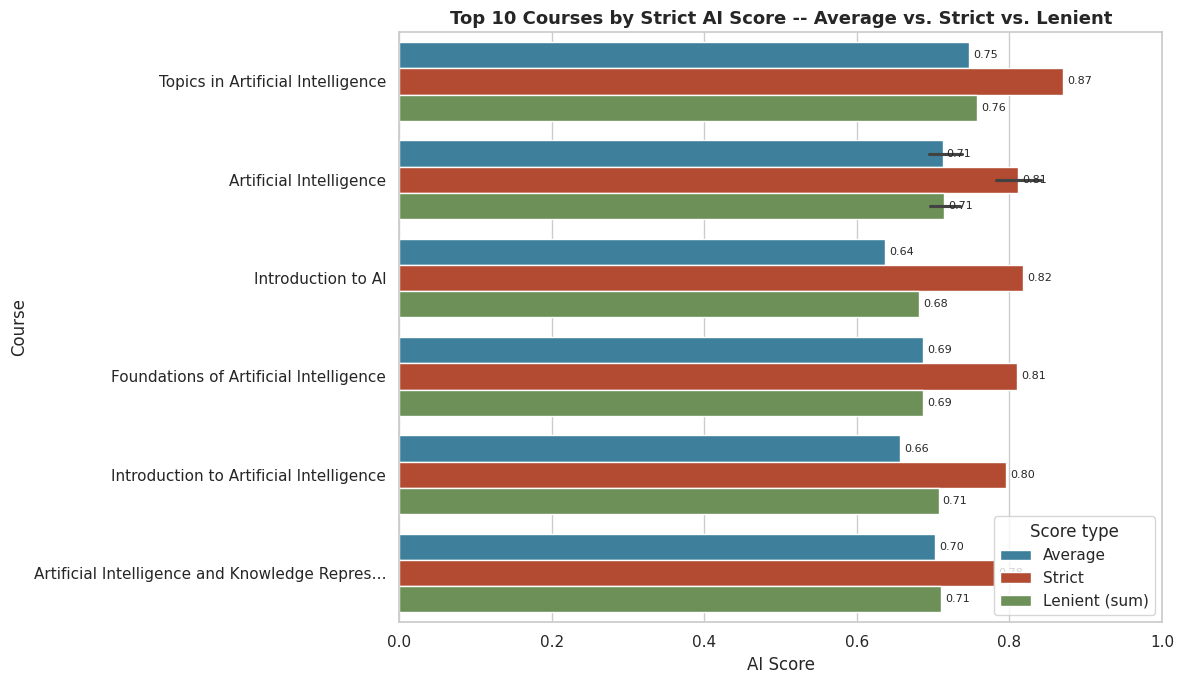

In [16]:
top = (df[[title_col, "strict_ai_count",
           "ai_avg_score", "strict_ai_score", "lenient_ai_score"]]
       .sort_values("strict_ai_score", ascending=False)
       .head(10).copy())
top["label"] = top[title_col].astype(str).apply(_wrap, width=45)

plot_df = top.melt(
    id_vars=["label"],
    value_vars=["ai_avg_score", "strict_ai_score", "lenient_ai_score"],
    var_name="Score type", value_name="Score",
)
label_map = {"ai_avg_score": "Average", "strict_ai_score": "Strict",
             "lenient_ai_score": "Lenient (sum)"}
plot_df["Score type"] = plot_df["Score type"].map(label_map)

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(data=plot_df, y="label", x="Score", hue="Score type",
            palette={"Average": "#2E86AB", "Strict": "#C73E1D",
                     "Lenient (sum)": "#6A994E"}, ax=ax)
ax.set_title("Top 10 Courses by Strict AI Score -- Average vs. Strict vs. Lenient",
             fontsize=13, fontweight="bold")
ax.set_xlabel("AI Score"); ax.set_ylabel("Course")
for p in ax.patches:
    w = p.get_width()
    if w and w > 0:
        ax.annotate(f"{w:.2f}", (w, p.get_y() + p.get_height() / 2),
                    ha="left", va="center", xytext=(3, 0),
                    textcoords="offset points", fontsize=8)
ax.legend(title="Score type", loc="lower right"); ax.margins(x=0.15)
plt.tight_layout(); plt.show()


### 6.2 Distribution of strict AI scores


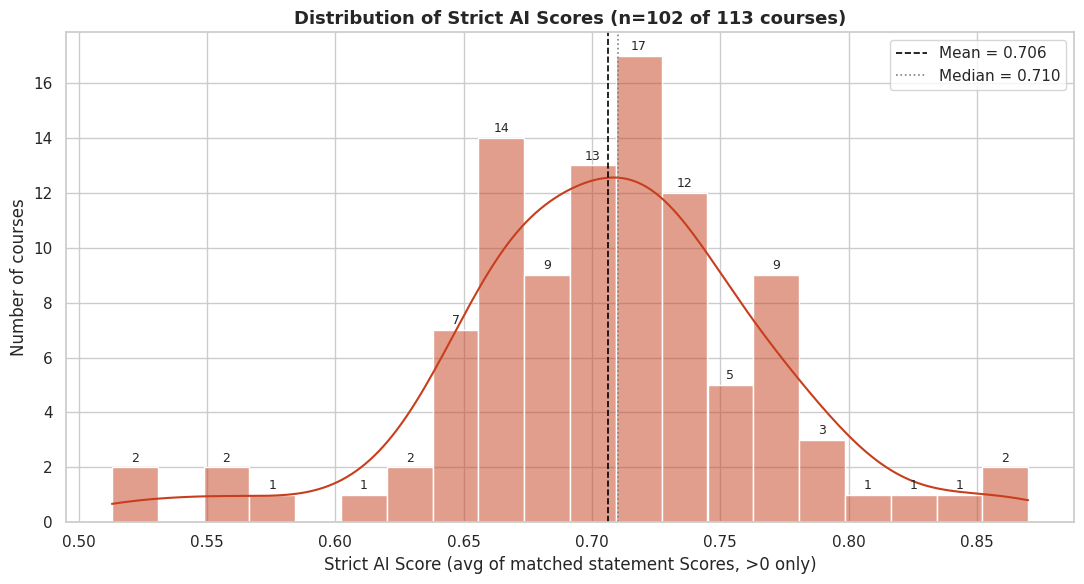

In [17]:
strict = df.loc[df["strict_ai_score"] > 0, "strict_ai_score"]
fig, ax = plt.subplots(figsize=(11, 6))
sns.histplot(strict, bins=20, kde=True, color="#C73E1D", ax=ax)
mean_s, median_s = strict.mean(), strict.median()
ax.axvline(mean_s,   color="black", linestyle="--", linewidth=1.2,
           label=f"Mean = {mean_s:.3f}")
ax.axvline(median_s, color="gray",  linestyle=":",  linewidth=1.2,
           label=f"Median = {median_s:.3f}")
ax.set_title(
    f"Distribution of Strict AI Scores (n={len(strict)} of {len(df)} courses)",
    fontsize=13, fontweight="bold")
ax.set_xlabel("Strict AI Score (avg of matched statement Scores, >0 only)")
ax.set_ylabel("Number of courses")
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f"{int(h)}",
                    (p.get_x() + p.get_width() / 2, h),
                    ha="center", va="bottom",
                    xytext=(0, 2), textcoords="offset points", fontsize=9)
ax.legend()
plt.tight_layout(); plt.show()


### 6.4 Top 10 AI concepts (AIMatch)


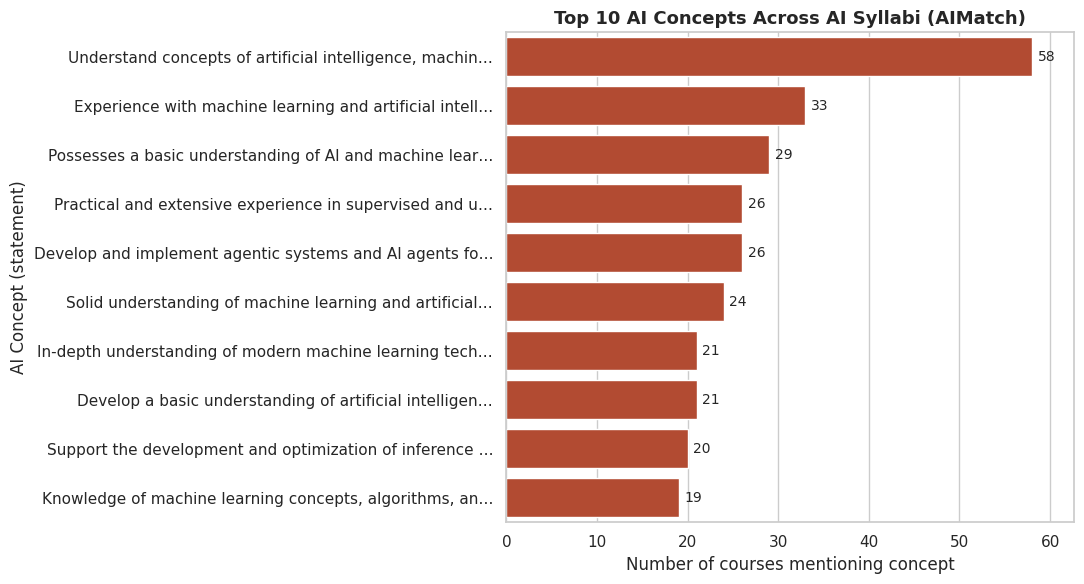

In [19]:
ai_counts = Counter(_flatten_labels(df["ai_concepts"], label_index=0)).most_common(10)
_bar_with_labels(
    ai_counts,
    title="Top 10 AI Concepts Across AI Syllabi (AIMatch)",
    xlabel="Number of courses mentioning concept",
    ylabel="AI Concept (statement)",
    color="#C73E1D",
    value_fmt="{:.0f}"
)

### 6.5 Top 10 O\*NET tasks (TaskMatch)


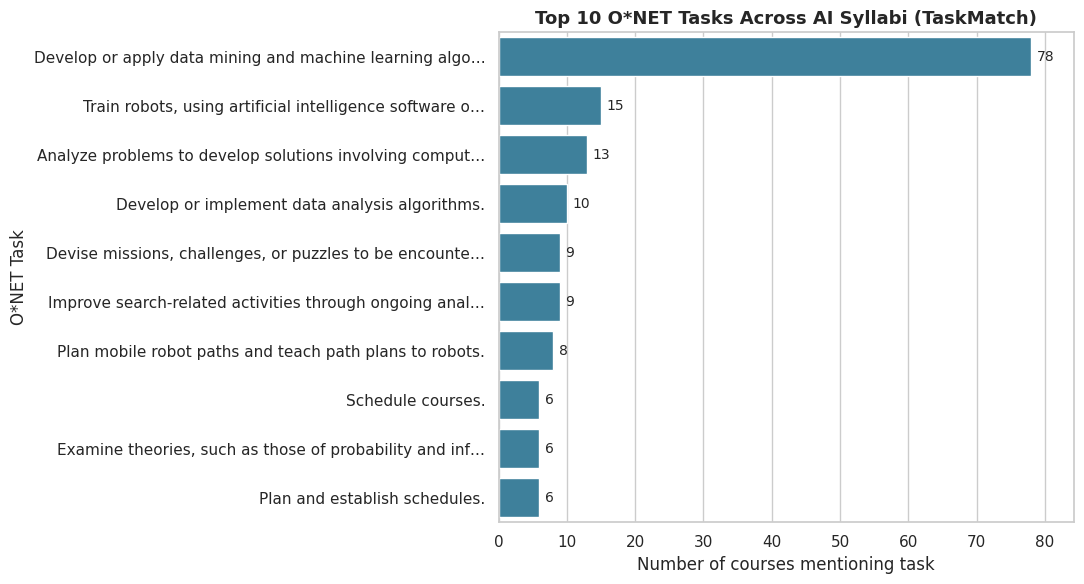

In [20]:
task_counts = Counter(_flatten_labels(df["tasks"], label_index=1)).most_common(10)
_bar_with_labels(
    task_counts,
    title="Top 10 O*NET Tasks Across AI Syllabi (TaskMatch)",
    xlabel="Number of courses mentioning task",
    ylabel="O*NET Task",
    color="#2E86AB",
    value_fmt="{:.0f}"
)

### 6.6 Top 10 ESCO skills (SkillMatch)


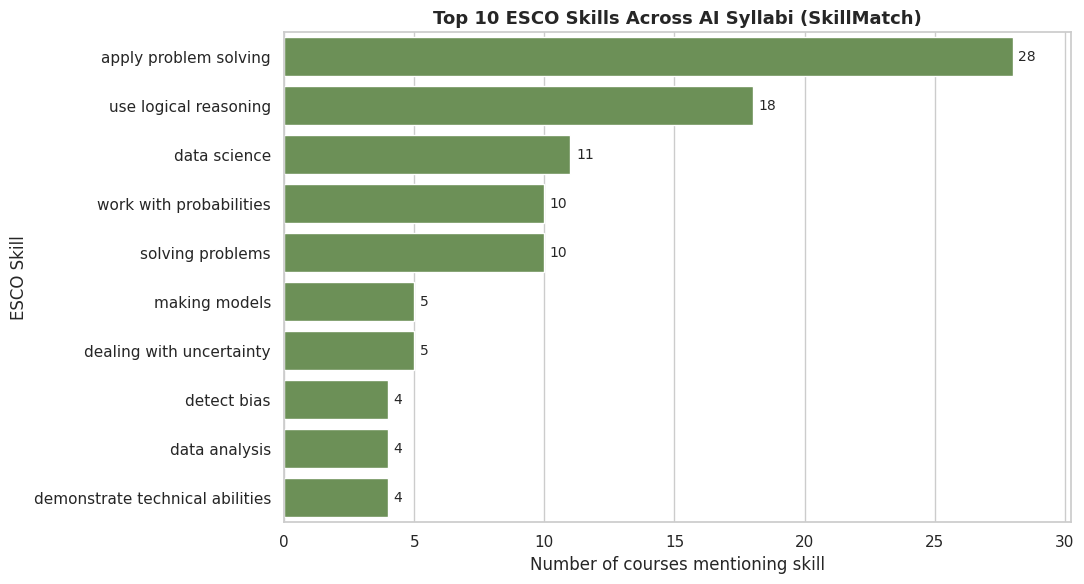

In [21]:
skill_counts = Counter(_flatten_labels(df["skills"], label_index=0)).most_common(10)
_bar_with_labels(
    skill_counts,
    title="Top 10 ESCO Skills Across AI Syllabi (SkillMatch)",
    xlabel="Number of courses mentioning skill",
    ylabel="ESCO Skill",
    color="#6A994E",
    value_fmt="{:.0f}"
)


### 6.7 Top 5 AI keywords (ConceptSearch) vs. Top 5 AI concepts (AIMatch)

Illustrates what the semantic model adds over literal keyword matching.


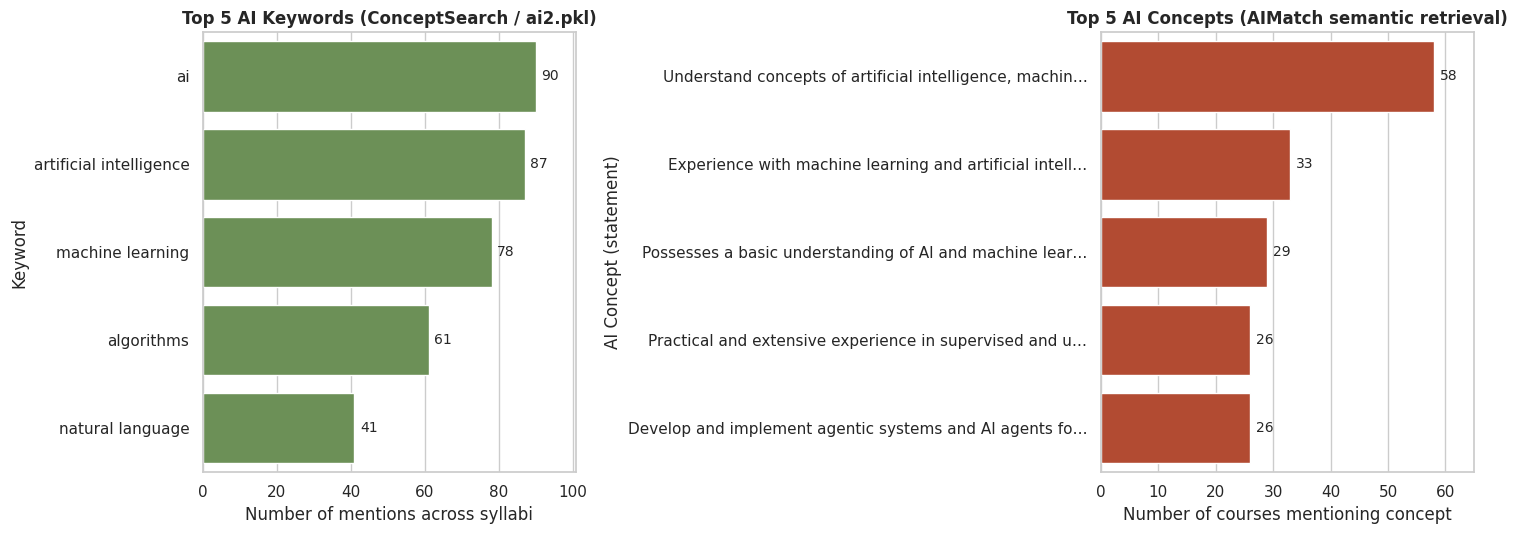

In [22]:
kw_counts = Counter(
    k for sub in df["ai_keywords"] for k in sub
).most_common(5)
concept_counts = Counter(
    _flatten_labels(df["ai_concepts"], label_index=0)
).most_common(5)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

kw_df = pd.DataFrame(kw_counts, columns=["Keyword", "Courses"])
sns.barplot(data=kw_df, y="Keyword", x="Courses", color="#6A994E", ax=axes[0])
axes[0].set_title("Top 5 AI Keywords (ConceptSearch / ai2.pkl)",
                  fontsize=12, fontweight="bold")
axes[0].set_xlabel("Number of mentions across syllabi")
axes[0].set_ylabel("Keyword")
for p in axes[0].patches:
    w = p.get_width()
    axes[0].annotate(f"{int(w)}",
                     (w, p.get_y() + p.get_height() / 2),
                     ha="left", va="center", xytext=(4, 0),
                     textcoords="offset points", fontsize=10)
axes[0].margins(x=0.12)

cc_df = pd.DataFrame(concept_counts, columns=["Concept", "Courses"])
cc_df["Concept"] = cc_df["Concept"].apply(lambda s: _wrap(s, width=55))
sns.barplot(data=cc_df, y="Concept", x="Courses", color="#C73E1D", ax=axes[1])
axes[1].set_title("Top 5 AI Concepts (AIMatch semantic retrieval)",
                  fontsize=12, fontweight="bold")
axes[1].set_xlabel("Number of courses mentioning concept")
axes[1].set_ylabel("AI Concept (statement)")
for p in axes[1].patches:
    w = p.get_width()
    axes[1].annotate(f"{int(w)}",
                     (w, p.get_y() + p.get_height() / 2),
                     ha="left", va="center", xytext=(4, 0),
                     textcoords="offset points", fontsize=10)
axes[1].margins(x=0.12)

plt.tight_layout(); plt.show()


### 6.8 AI keyword hits vs. strict AI concept matches (per course)


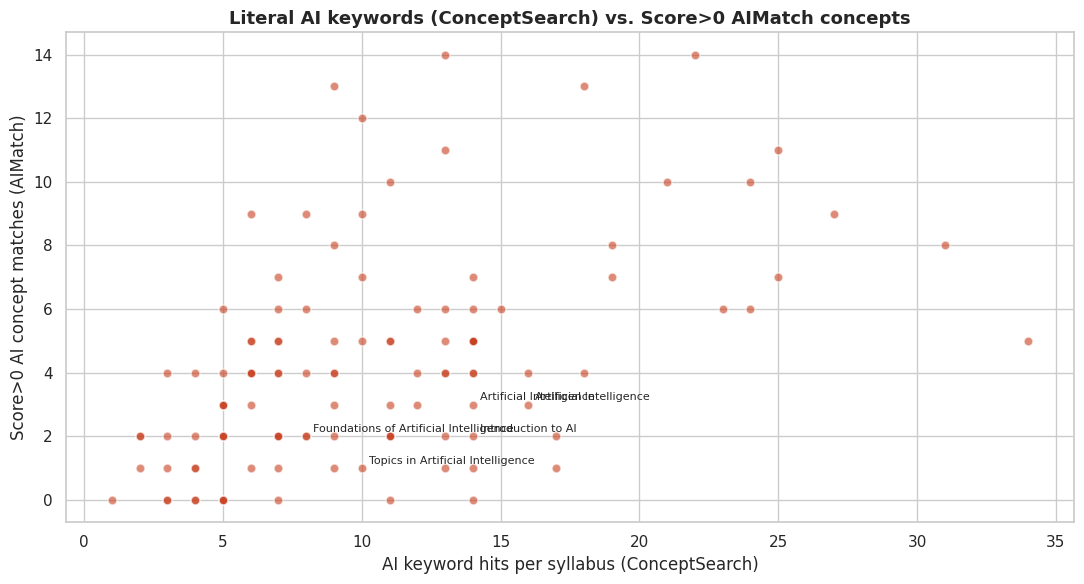

In [23]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.scatter(df["ai_keyword_count"], df["strict_ai_count"],
           s=40, alpha=0.6, color="#C73E1D", edgecolor="white")
ax.set_title("Literal AI keywords (ConceptSearch) vs. Score>0 AIMatch concepts",
             fontsize=13, fontweight="bold")
ax.set_xlabel("AI keyword hits per syllabus (ConceptSearch)")
ax.set_ylabel("Score>0 AI concept matches (AIMatch)")
for _, row in df.nlargest(5, "strict_ai_score").iterrows():
    ax.annotate(_wrap(row[title_col], width=40),
                (row["ai_keyword_count"], row["strict_ai_count"]),
                xytext=(5, 3), textcoords="offset points", fontsize=8)
plt.tight_layout(); plt.show()


## 7. Save Results

In [24]:
output_file = 'AI_course_syllabi_analyzed.xlsx'
df.to_excel(output_file, index=False)
print(f"Results saved to {output_file}")

Results saved to AI_course_syllabi_analyzed.xlsx
